In [1]:
import spatialdata as sd
import datashader as ds
import shapely as sp
import pandas as pd
import colorcet

import spatialdata_plot

import dask

import json
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

/mnt/hdd1/leiden-cellseg/task_spatial_segmentation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sdata = sd.read_zarr("../data/datasets/gt_annotated_data/WTA_Preview_FFPE_Breast_Cancer_Aligned_subset.zarr")
sdata

SpatialData object, with associated Zarr store: /mnt/hdd1/leiden-cellseg/task_spatial_segmentation/data/datasets/gt_annotated_data/WTA_Preview_FFPE_Breast_Cancer_Aligned_subset.zarr
├── Images
│     ├── 'hne_aligned': DataArray[cyx] (3, 2747, 2923)
│     └── 'morphology_focus': DataTree[cyx] (4, 3725, 2779), (4, 1863, 1389), (4, 931, 695), (4, 466, 347), (4, 233, 174)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (3725, 2779), (1863, 1389), (931, 695), (466, 347), (233, 174)
│     └── 'nucleus_labels': DataTree[yx] (3725, 2779), (1863, 1389), (931, 695), (466, 347), (233, 174)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (1975, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (1961, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (1973, 18028)
with coordinate systems:
    ▸ 'global', with elements:
        hne_aligned (Images), morphology_focus (Images), cell_l

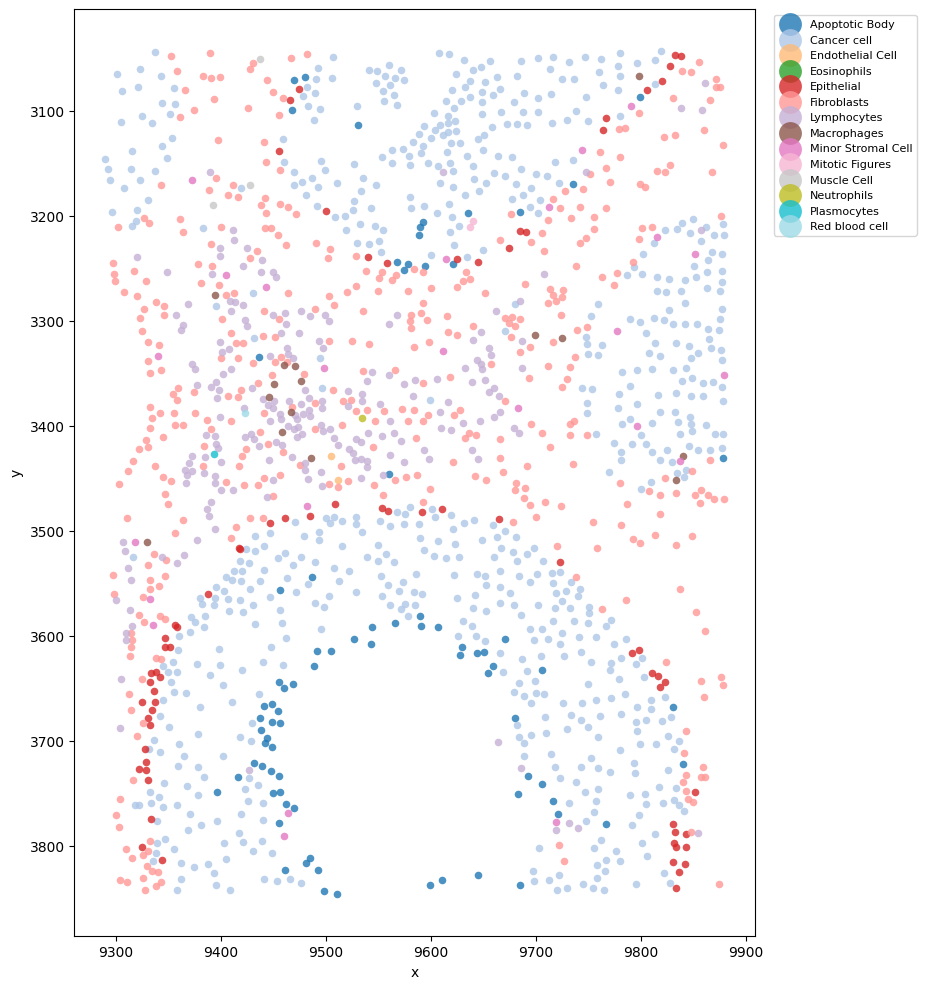

In [3]:
x_spatial = sdata.tables['table'].obsm['X_spatial']
classes = sdata['table'].obs['histoplus_cell_class']

# stable color per class
cats = pd.Categorical(classes)
cmap = plt.get_cmap('tab20', len(cats.categories))

fig, ax = plt.subplots(figsize=(10, 10))
for code, name in enumerate(cats.categories):
    m = cats.codes == code
    ax.scatter(x_spatial[m, 0], x_spatial[m, 1],
               s=30, c=[cmap(code)], label=name, alpha=0.8, linewidths=0)

ax.set_aspect('equal')
ax.invert_yaxis()                          # image-style y axis
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(markerscale=3, fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

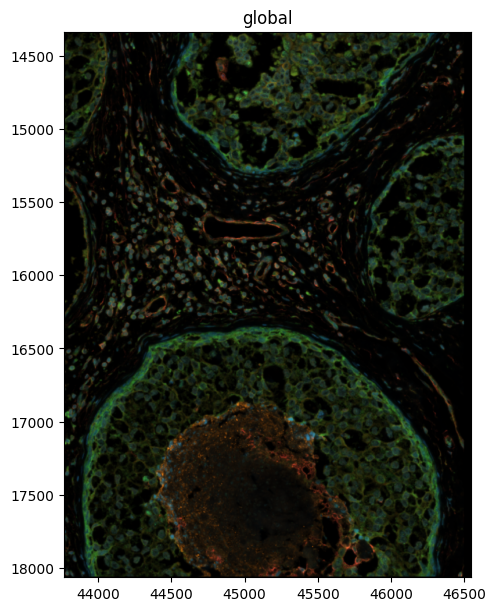

In [4]:
sdata.pl.render_images("morphology_focus").pl.show(figsize=(6, 6))

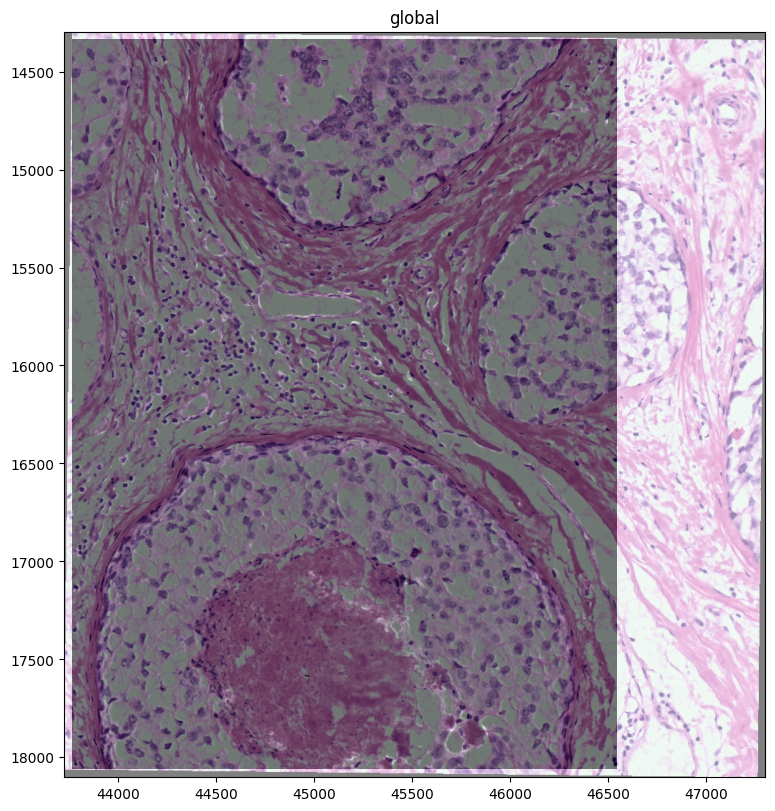

In [6]:
(sdata
    .pl.render_images("morphology_focus", cmap="gray")
    .pl.render_images("hne_aligned", alpha=0.5)
    .pl.show(figsize=(8, 8))
)

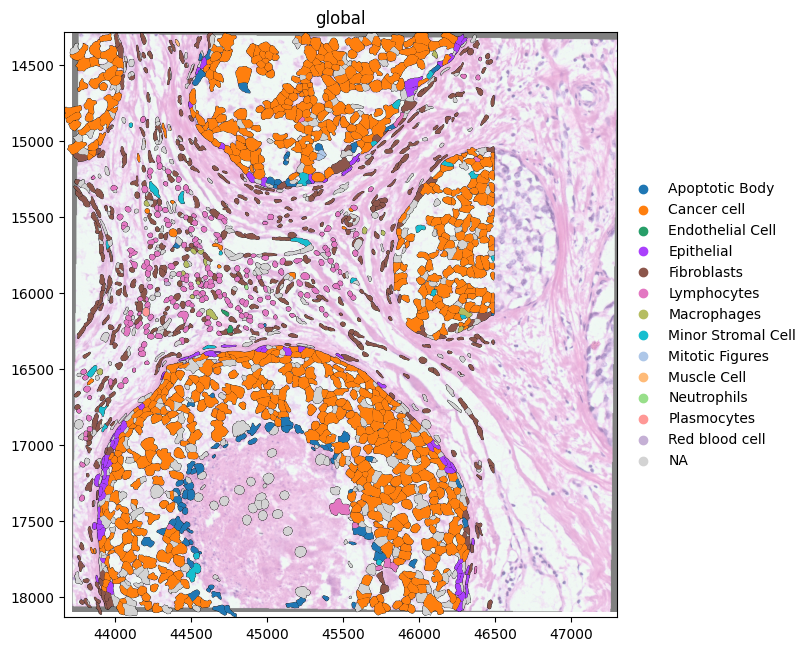

In [9]:
# join class onto the polygons by cell index
table = sdata["table"]
classes = pd.Series(
    table.obs["histoplus_cell_class"].values,
    index=table.obs_names,
)
sdata["cell_boundaries"]["histoplus_cell_class"] = (
    sdata["cell_boundaries"].index.map(classes)
)

(sdata
    .pl.render_images("hne_aligned", alpha=0.5)
    .pl.render_shapes(
        "cell_boundaries",
        color="histoplus_cell_class",
        fill_alpha=1,
        outline_alpha=1,
        outline_width=0.5,
    )
    .pl.show(figsize=(8, 8))
)